## Business Case: To predict the salary of employees using given features

In [1]:
## Importing the Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import klib
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.svm import SVR
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [3]:
## Importing the dataset
df=pd.read_csv('salary.csv')
df

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,...,12.93000,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN


## Basic Checks:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

In [5]:
df.describe()

,AGENCY,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,multiple_full_time_jobs,summed_annual_salary
count,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000,1.494810e+05,14.0,16.000000
mean,545.736288,0.346488,39.714918,4226.184248,50714.210973,5.651930e+05,1.0,74303.955000
std,139.057691,4.211485,2.323855,2093.111691,25117.340292,4.786212e+05,0.0,51925.944282
min,101.000000,0.000000,1.000000,50.000000,600.000000,1.000000e+00,1.0,18000.000000
25%,529.000000,0.000000,40.000000,3019.840000,36238.080000,1.133340e+05,1.0,32962.500000
50%,530.000000,0.000000,40.000000,3720.170000,44642.040000,3.463730e+05,1.0,48063.300000
75%,696.000000,0.000000,40.000000,4865.810000,58389.720000,1.100500e+06,1.0,123751.770000
max,930.000000,117.788480,70.000000,46125.000000,553500.000000,1.271604e+06,1.0,171383.400000


In [6]:
df.describe(include='O')

,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,duplicated,combined_multiple_jobs,hide_from_search
count,149481,149481,149481,149481,149481,149481,149481,149481,149481,149481,143,97,16
unique,113,38675,23559,27,1481,1422,6,2,11,6295,1,1,1
top,HEALTH AND HUMAN SERVICES COMMISSION ...,SMITH,MICHAEL,,4504,CORREC OFFICER IV ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/01/17,True,True,True
freq,36667,1243,1843,38408,9267,9267,67142,85328,142502,12359,143,97,16


In [7]:
df.dtypes

AGENCY                       int64
AGENCY NAME                 object
LAST NAME                   object
FIRST NAME                  object
MI                          object
CLASS CODE                  object
CLASS TITLE                 object
ETHNICITY                   object
GENDER                      object
STATUS                      object
EMPLOY DATE                 object
HRLY RATE                  float64
HRS PER WK                 float64
MONTHLY                    float64
ANNUAL                     float64
STATE NUMBER                 int64
duplicated                  object
multiple_full_time_jobs    float64
combined_multiple_jobs      object
summed_annual_salary       float64
hide_from_search            object
dtype: object

In [8]:
df.drop(columns={'duplicated','multiple_full_time_jobs','combined_multiple_jobs','summed_annual_salary','hide_from_search',
                'STATE NUMBER','EMPLOY DATE','LAST NAME','FIRST NAME'},inplace=True)

In [9]:
## Renaming the columns
df.rename(columns={"AGENCY NAME":'AGENCY_NAME',"CLASS CODE":'CLASS_CODE',"CLASS TITLE":'CLASS_TITLE',"HRLY RATE":'HRLY_RATE',
                   "HRS PER WK":'HRS_PER_WK',},inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   AGENCY       149481 non-null  int64  
 1   AGENCY_NAME  149481 non-null  object 
 2   MI           149481 non-null  object 
 3   CLASS_CODE   149481 non-null  object 
 4   CLASS_TITLE  149481 non-null  object 
 5   ETHNICITY    149481 non-null  object 
 6   GENDER       149481 non-null  object 
 7   STATUS       149481 non-null  object 
 8   HRLY_RATE    149481 non-null  float64
 9   HRS_PER_WK   149481 non-null  float64
 10  MONTHLY      149481 non-null  float64
 11  ANNUAL       149481 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 13.7+ MB


In [11]:
df.isnull().sum()

AGENCY         0
AGENCY_NAME    0
MI             0
CLASS_CODE     0
CLASS_TITLE    0
ETHNICITY      0
GENDER         0
STATUS         0
HRLY_RATE      0
HRS_PER_WK     0
MONTHLY        0
ANNUAL         0
dtype: int64

In [12]:
df.nunique()

AGENCY           113
AGENCY_NAME      113
MI                27
CLASS_CODE      1481
CLASS_TITLE     1422
ETHNICITY          6
GENDER             2
STATUS            11
HRLY_RATE        206
HRS_PER_WK        58
MONTHLY        40552
ANNUAL         40554
dtype: int64

In [13]:
df.duplicated().sum()

55131

In [14]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [15]:
df.corr()

,AGENCY,HRLY_RATE,HRS_PER_WK,MONTHLY,ANNUAL
AGENCY,1.000000,-0.010220,-0.033574,-0.192809,-0.192809
HRLY_RATE,-0.010220,1.000000,-0.348250,-0.000925,-0.000925
HRS_PER_WK,-0.033574,-0.348250,1.000000,0.131676,0.131676
MONTHLY,-0.192809,-0.000925,0.131676,1.000000,1.000000
ANNUAL,-0.192809,-0.000925,0.131676,1.000000,1.000000


## EDA Using klib library

Large dataset detected, using 10000 random samples for the plots. Summary statistics are still based on the entire dataset.


<AxesSubplot:xlabel='ANNUAL', ylabel='Density'>

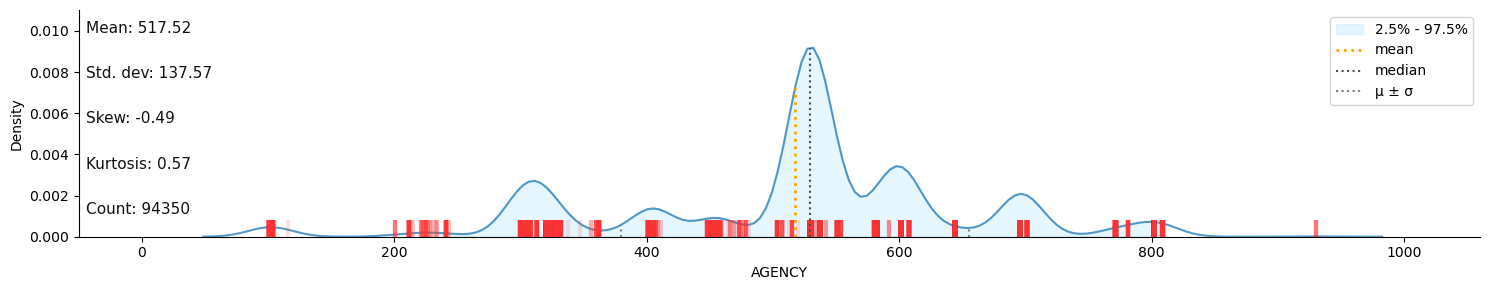

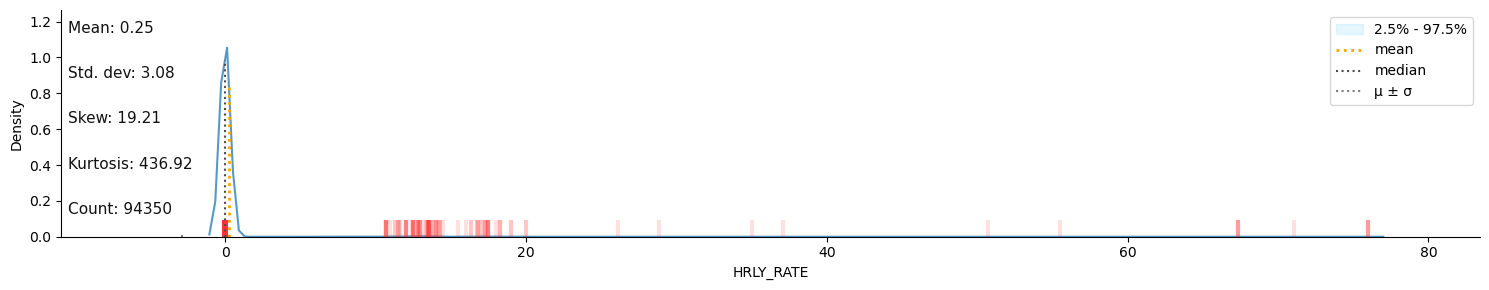

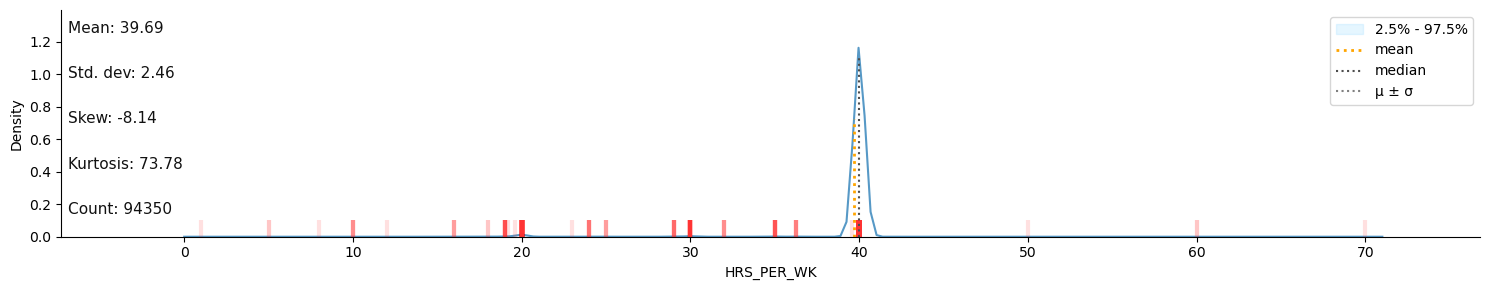

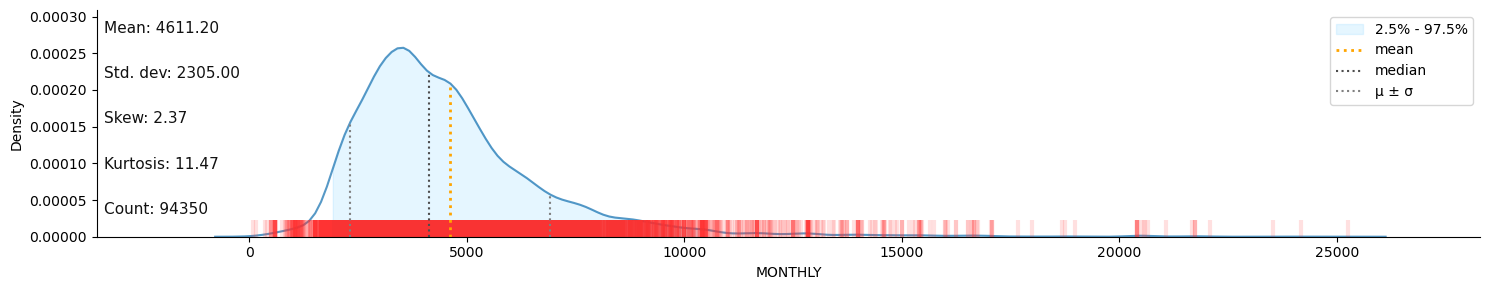

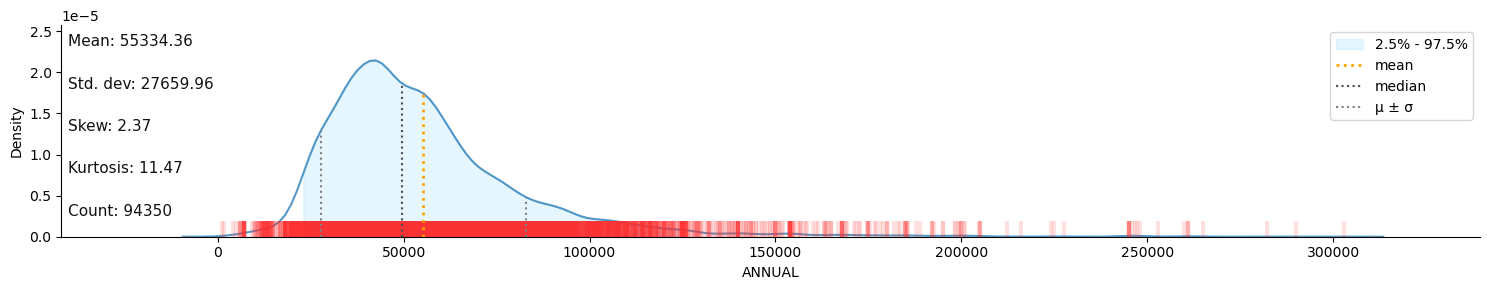

In [16]:
klib.dist_plot(df) # returns a distribution plot for every numeric feature

In [17]:
klib.missingval_plot(df) # returns a figure containing information about missing values

No missing values found in the dataset.


## Data Cleaning using Klib Library

In [18]:
# klib.clean - functions for cleaning datasets
klib.data_cleaning(df) # performs datacleaning (drop duplicates & empty rows/cols, adjust dtypes,...)

Shape of cleaned data: (94350, 12) - Remaining NAs: 0


Dropped rows: 0
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 8.85 MB (-77.84%)



,agency,agency_name,mi,class_code,class_title,ethnicity,gender,status,hrly_rate,hrs_per_wk,monthly,annual
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.961502,29.0,9545.820312,114549.843750
1,212,OFFICE OF COURT ADMINISTRATION ...,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.044540,4.0,1404.770020,16857.240234
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.961502,29.0,9545.820312,114549.843750
3,212,OFFICE OF COURT ADMINISTRATION ...,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.044533,4.0,1404.770020,16857.240234
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.000000,40.0,3284.270020,39411.238281
...,...,...,...,...,...,...,...,...,...,...,...,...
94345,809,STATE PRESERVATION BOARD ...,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.000000,40.0,2899.000000,34788.000000
94346,809,STATE PRESERVATION BOARD ...,A,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.000000,40.0,5500.000000,66000.000000
94347,809,STATE PRESERVATION BOARD ...,C,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,12.930000,20.0,1120.599976,13447.200195
94348,809,STATE PRESERVATION BOARD ...,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.000000,40.0,5744.160156,68929.921875


In [19]:
klib.clean_column_names(df) # cleans and standardizes column names, also called inside data_cleaning()

,agency,agency_name,mi,class_code,class_title,ethnicity,gender,status,hrly_rate,hrs_per_wk,monthly,annual
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,9545.82,114549.84
1,212,OFFICE OF COURT ADMINISTRATION ...,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04454,4.0,1404.77,16857.24
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,9545.82,114549.84
3,212,OFFICE OF COURT ADMINISTRATION ...,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04453,4.0,1404.77,16857.24
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,3284.27,39411.24
...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,2899.00,34788.00
149477,809,STATE PRESERVATION BOARD ...,A,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,5500.00,66000.00
149478,809,STATE PRESERVATION BOARD ...,C,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,12.93000,20.0,1120.60,13447.20
149479,809,STATE PRESERVATION BOARD ...,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,5744.16,68929.92


In [20]:
df=klib.convert_datatypes(df) # converts existing to more efficient dtypes, also called inside data_cleaning()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 94350 entries, 0 to 149480
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   agency       94350 non-null  int16   
 1   agency_name  94350 non-null  category
 2   mi           94350 non-null  category
 3   class_code   94350 non-null  category
 4   class_title  94350 non-null  category
 5   ethnicity    94350 non-null  category
 6   gender       94350 non-null  category
 7   status       94350 non-null  category
 8   hrly_rate    94350 non-null  float32 
 9   hrs_per_wk   94350 non-null  float32 
 10  monthly      94350 non-null  float32 
 11  annual       94350 non-null  float32 
dtypes: category(7), float32(4), int16(1)
memory usage: 5.3 MB


In [21]:
klib.mv_col_handling(df)

,agency,agency_name,mi,class_code,class_title,ethnicity,gender,status,hrly_rate,hrs_per_wk,monthly,annual
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.961502,29.0,9545.820312,114549.843750
1,212,OFFICE OF COURT ADMINISTRATION ...,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.044540,4.0,1404.770020,16857.240234
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.961502,29.0,9545.820312,114549.843750
3,212,OFFICE OF COURT ADMINISTRATION ...,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.044533,4.0,1404.770020,16857.240234
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.000000,40.0,3284.270020,39411.238281
...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.000000,40.0,2899.000000,34788.000000
149477,809,STATE PRESERVATION BOARD ...,A,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.000000,40.0,5500.000000,66000.000000
149478,809,STATE PRESERVATION BOARD ...,C,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,12.930000,20.0,1120.599976,13447.200195
149479,809,STATE PRESERVATION BOARD ...,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.000000,40.0,5744.160156,68929.921875


## Exploratory Data Analysis(EDA)

### Univariate Analysis

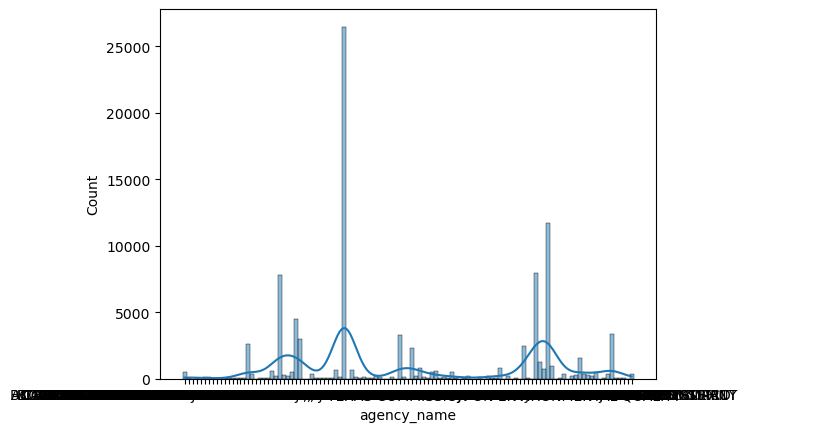

In [22]:
# Histogram
sns.histplot(x='agency_name',data=df,kde=True) # kde:kernel density estimation
plt.show()   # univariate analysis

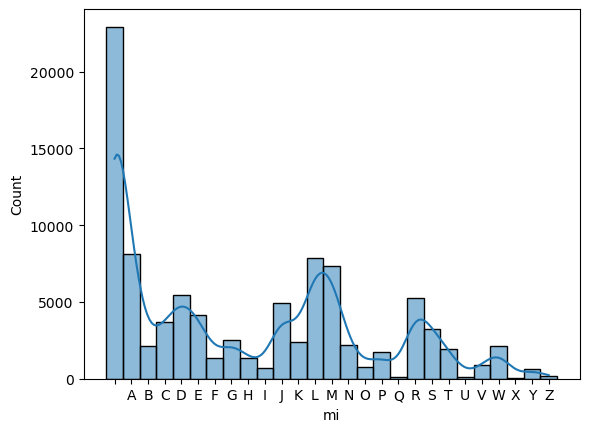

In [23]:
# Histogram
sns.histplot(x='mi',data=df,kde=True) # kde:kernel density estimation
plt.show()   # univariate analysis

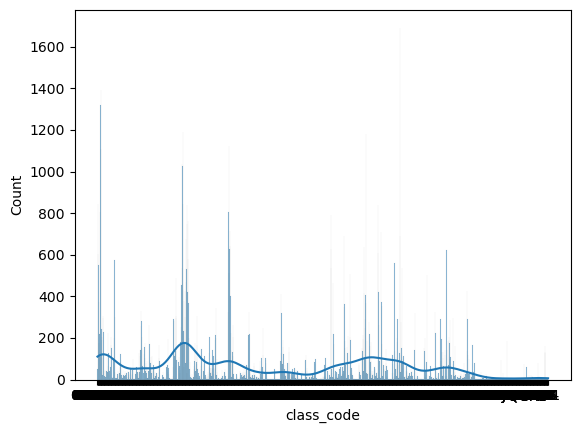

In [24]:
# Histogram
sns.histplot(x='class_code',data=df,kde=True) # kde:kernel density estimation
plt.show()   # univariate analysis

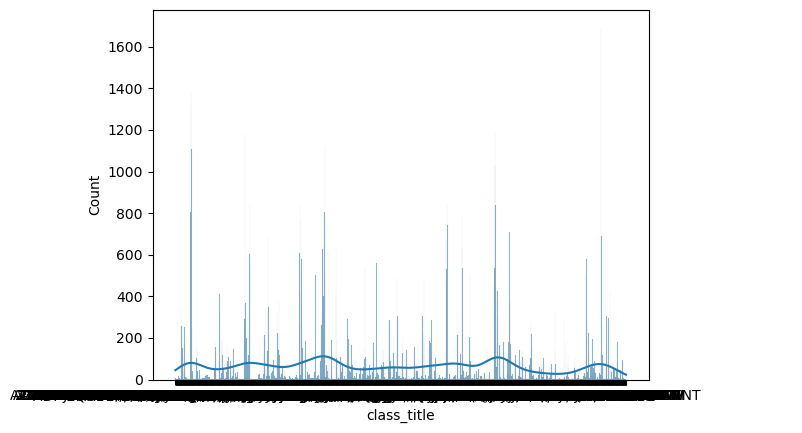

In [25]:
# Histogram
sns.histplot(x='class_title',data=df,kde=True) # kde:kernel density estimation
plt.show()   # univariate analysis

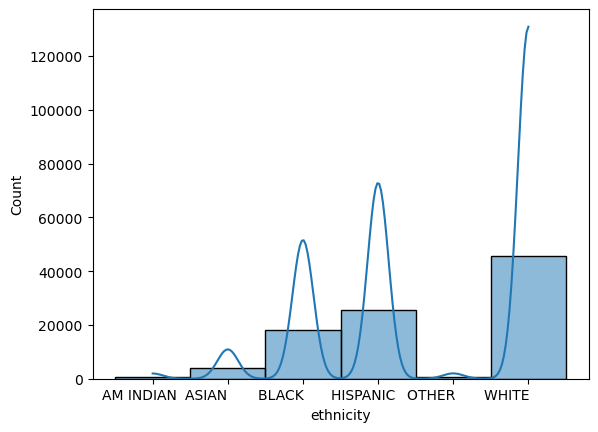

In [26]:
# Histogram
sns.histplot(x='ethnicity',data=df,kde=True) # kde:kernel density estimation
plt.show()   # univariate analysis

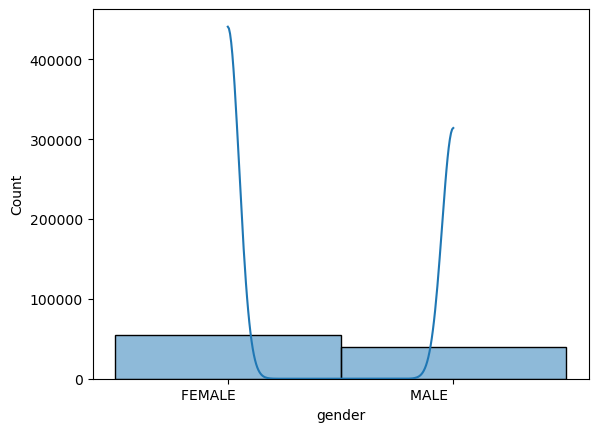

In [27]:
# Histogram
sns.histplot(x='gender',data=df,kde=True) # kde:kernel density estimation
plt.show()   # univariate analysis

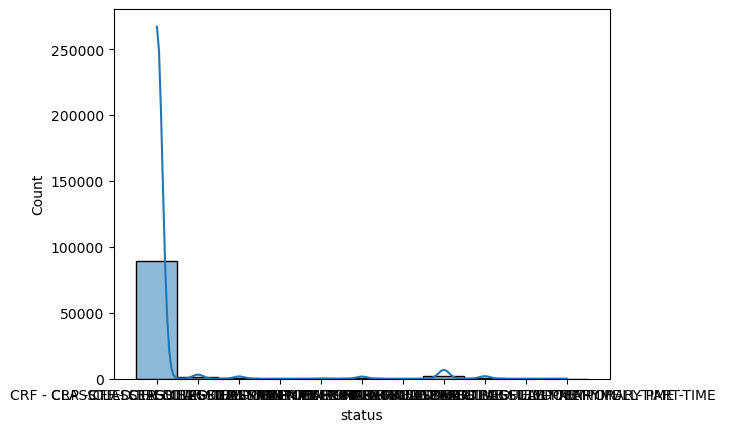

In [28]:
# Histogram
sns.histplot(x='status',data=df,kde=True) # kde:kernel density estimation
plt.show()   # univariate analysis

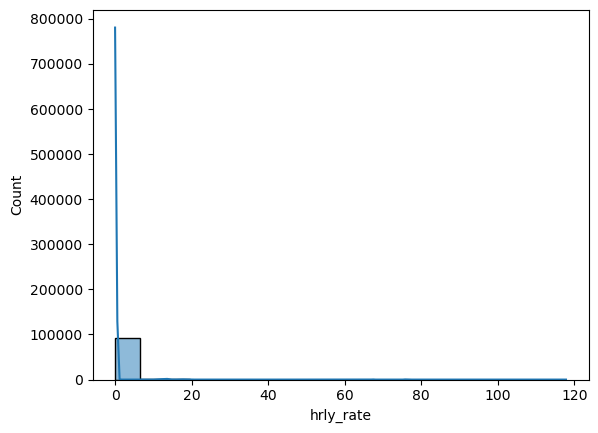

In [29]:
# Histogram
sns.histplot(x='hrly_rate',data=df,kde=True) # kde:kernel density estimation
plt.show()   # univariate analysis

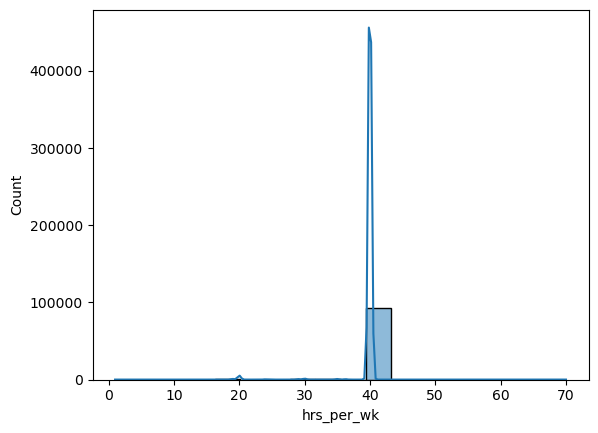

In [30]:
# Histogram
sns.histplot(x='hrs_per_wk',data=df,kde=True) # kde:kernel density estimation
plt.show()   # univariate analysis

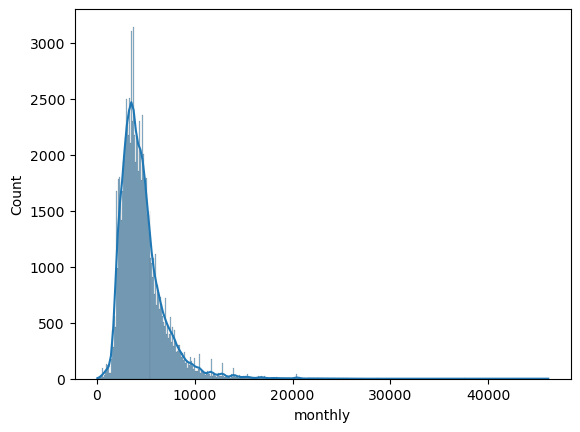

In [31]:
# Histogram
sns.histplot(x='monthly',data=df,kde=True) # kde:kernel density estimation
plt.show()   # univariate analysis

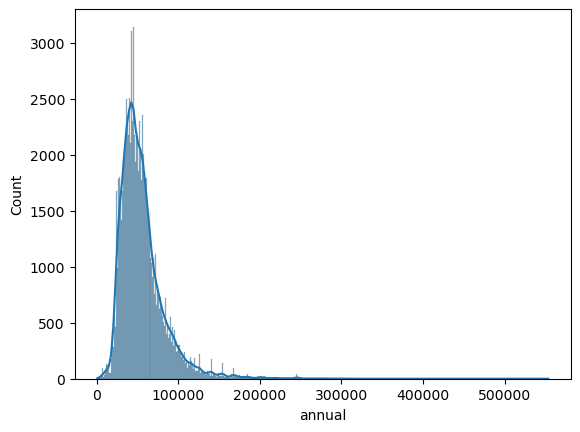

In [32]:
# Histogram
sns.histplot(x='annual',data=df,kde=True) # kde:kernel density estimation
plt.show()   # univariate analysis

<AxesSubplot:xlabel='agency_name', ylabel='count'>

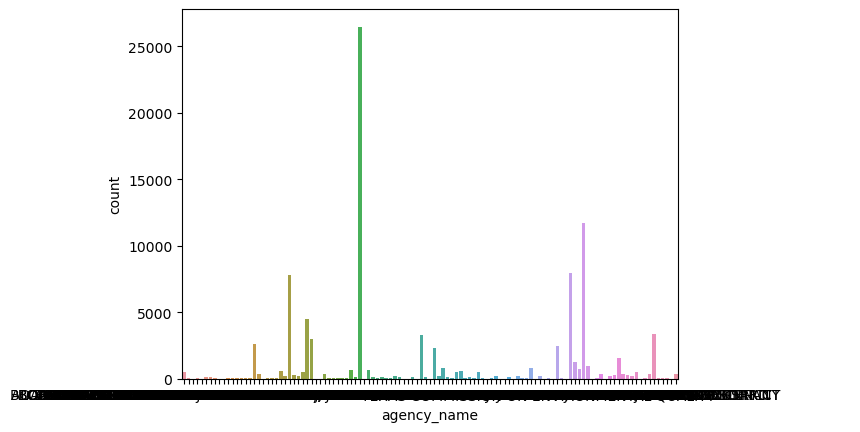

In [33]:
sns.countplot(x='agency_name',data=df)

<AxesSubplot:xlabel='mi', ylabel='count'>

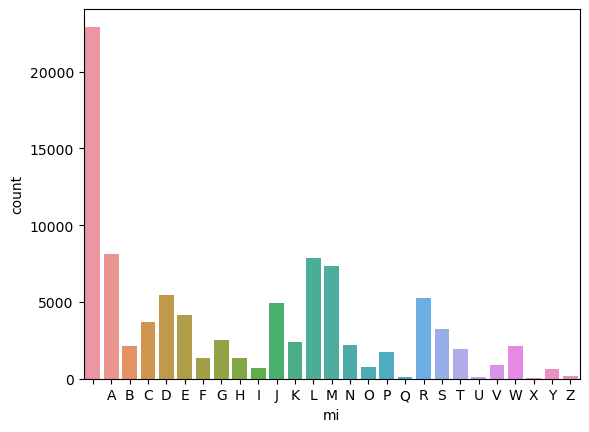

In [34]:
sns.countplot(x='mi',data=df)

<AxesSubplot:xlabel='class_code', ylabel='count'>

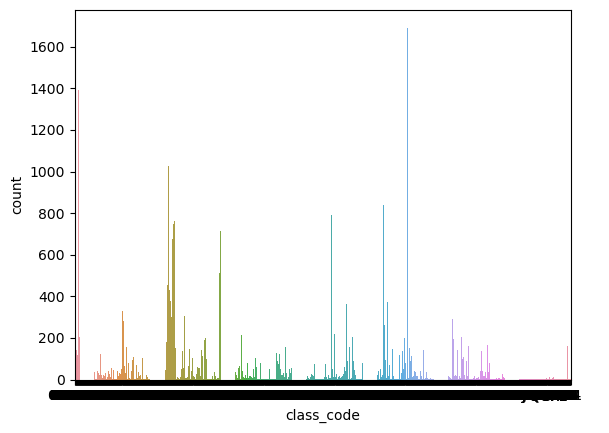

In [35]:
sns.countplot(x='class_code',data=df)

<AxesSubplot:xlabel='class_title', ylabel='count'>

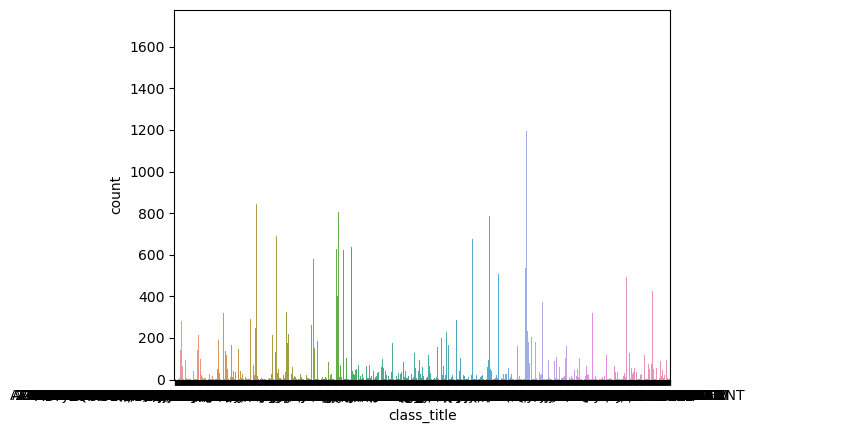

In [36]:
sns.countplot(x='class_title',data=df)

<AxesSubplot:xlabel='ethnicity', ylabel='count'>

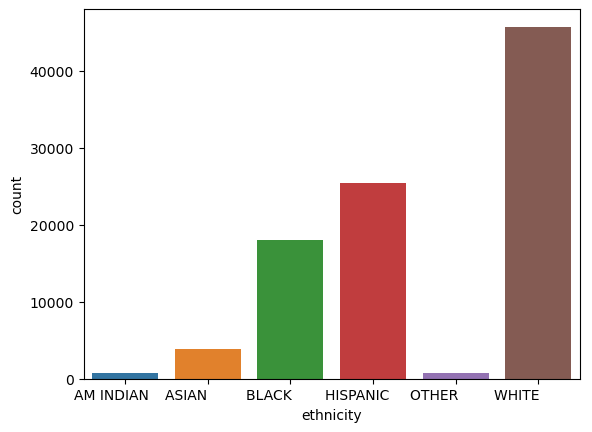

In [37]:
sns.countplot(x='ethnicity',data=df)

<AxesSubplot:xlabel='gender', ylabel='count'>

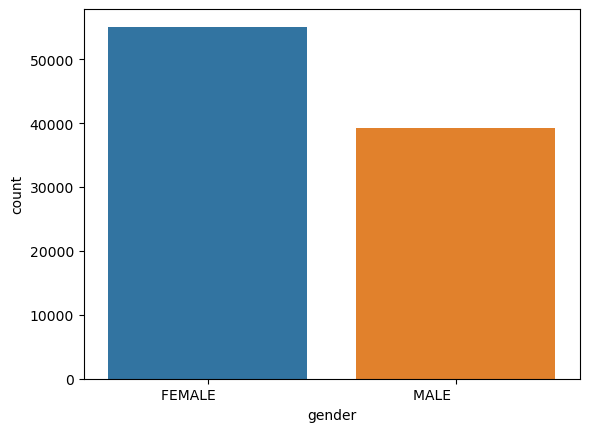

In [38]:
sns.countplot(x='gender',data=df)

<AxesSubplot:xlabel='status', ylabel='count'>

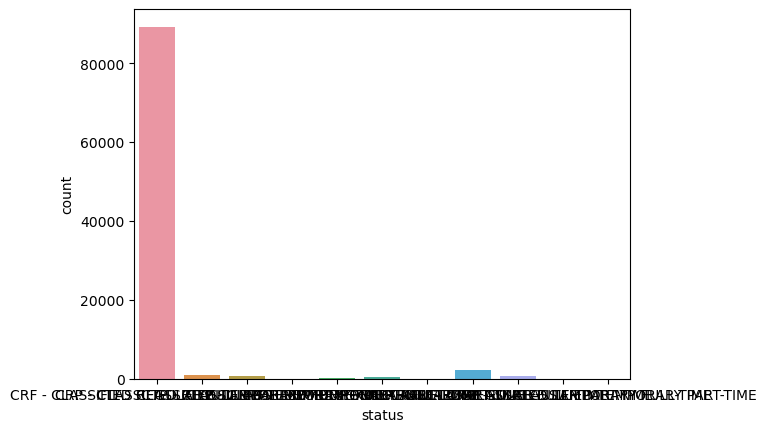

In [39]:
sns.countplot(x='status',data=df)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 94350 entries, 0 to 149480
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   agency       94350 non-null  int16   
 1   agency_name  94350 non-null  category
 2   mi           94350 non-null  category
 3   class_code   94350 non-null  category
 4   class_title  94350 non-null  category
 5   ethnicity    94350 non-null  category
 6   gender       94350 non-null  category
 7   status       94350 non-null  category
 8   hrly_rate    94350 non-null  float32 
 9   hrs_per_wk   94350 non-null  float32 
 10  monthly      94350 non-null  float32 
 11  annual       94350 non-null  float32 
dtypes: category(7), float32(4), int16(1)
memory usage: 5.3 MB


### Bi-variate Analysis

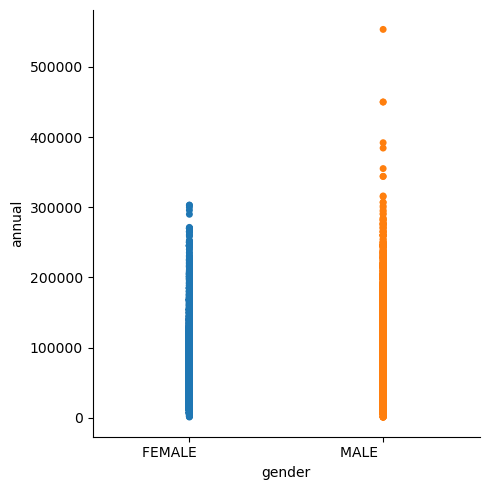

In [41]:
sns.catplot(x='gender',y='annual',jitter=False,data=df)
plt.show()

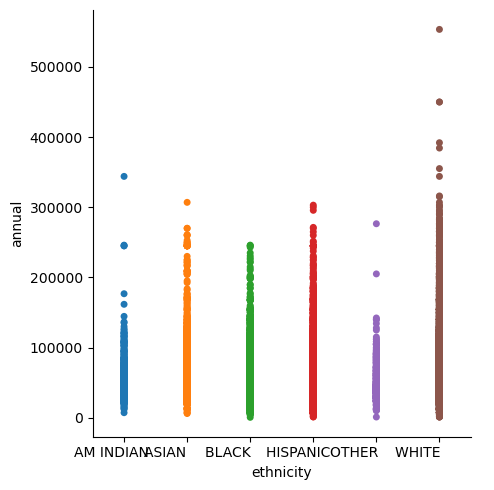

In [42]:
sns.catplot(x='ethnicity',y='annual',jitter=False,data=df)
plt.show()

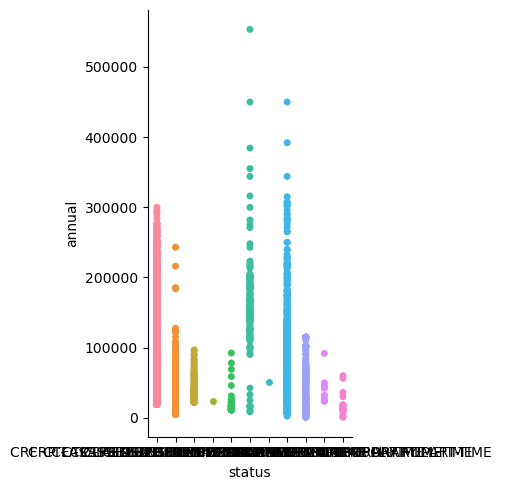

In [43]:
sns.catplot(x='status',y='annual',jitter=False,data=df)
plt.show()

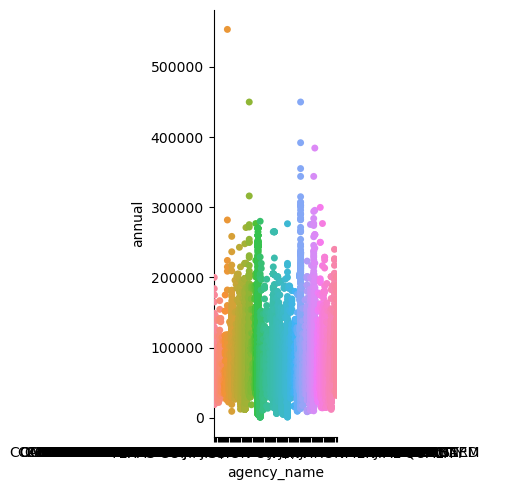

In [44]:
sns.catplot(x='agency_name',y='annual',jitter=False,data=df)
plt.show()

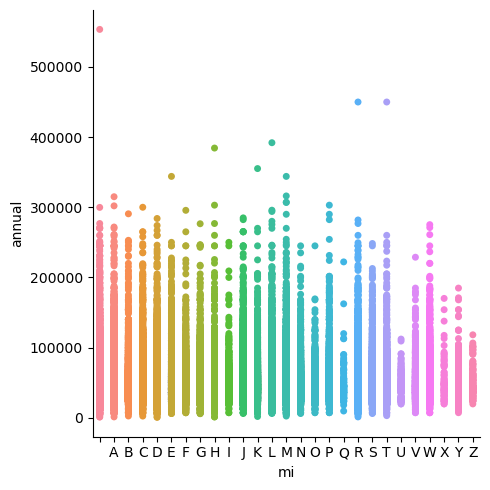

In [45]:
sns.catplot(x='mi',y='annual',jitter=False,data=df)
plt.show()

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 94350 entries, 0 to 149480
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   agency       94350 non-null  int16   
 1   agency_name  94350 non-null  category
 2   mi           94350 non-null  category
 3   class_code   94350 non-null  category
 4   class_title  94350 non-null  category
 5   ethnicity    94350 non-null  category
 6   gender       94350 non-null  category
 7   status       94350 non-null  category
 8   hrly_rate    94350 non-null  float32 
 9   hrs_per_wk   94350 non-null  float32 
 10  monthly      94350 non-null  float32 
 11  annual       94350 non-null  float32 
dtypes: category(7), float32(4), int16(1)
memory usage: 5.3 MB


In [47]:
## Barplot

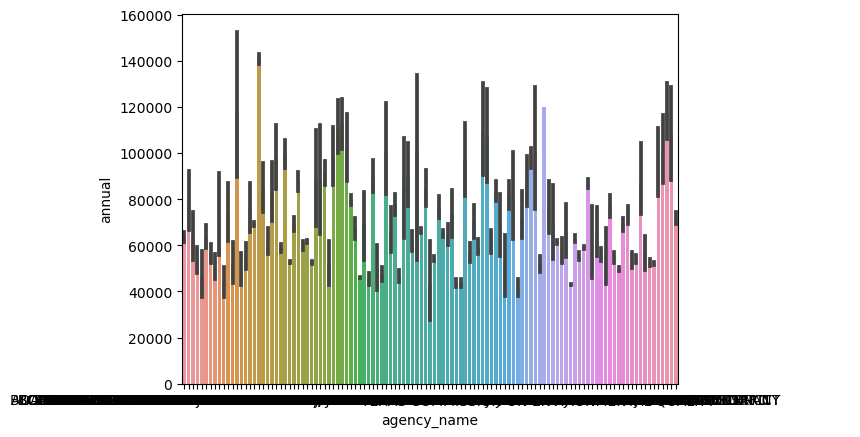

In [48]:
# Bar plot
sns.barplot(x='agency_name',y='annual',data=df) 
plt.show()

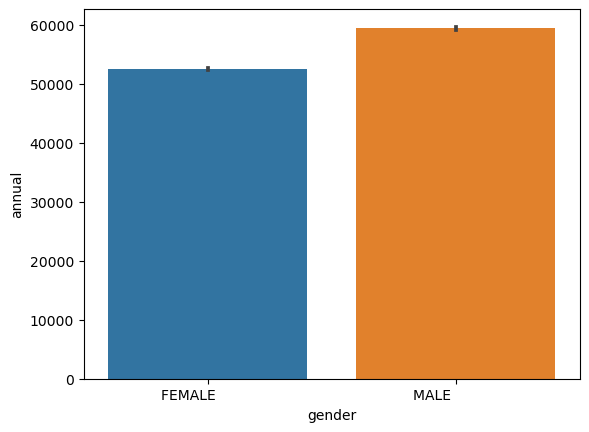

In [49]:
# Bar plot
sns.barplot(x='gender',y='annual',data=df) 
plt.show()

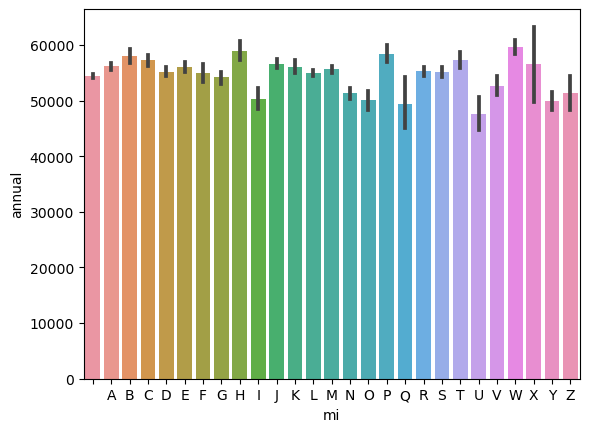

In [50]:
# Bar plot
sns.barplot(x='mi',y='annual',data=df) 
plt.show()

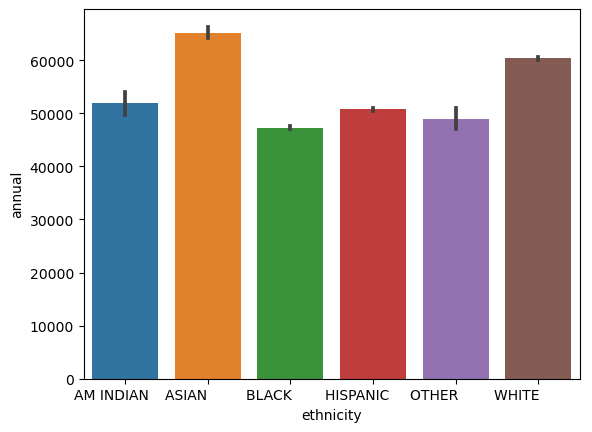

In [51]:
# Bar plot
sns.barplot(x='ethnicity',y='annual',data=df) 
plt.show()

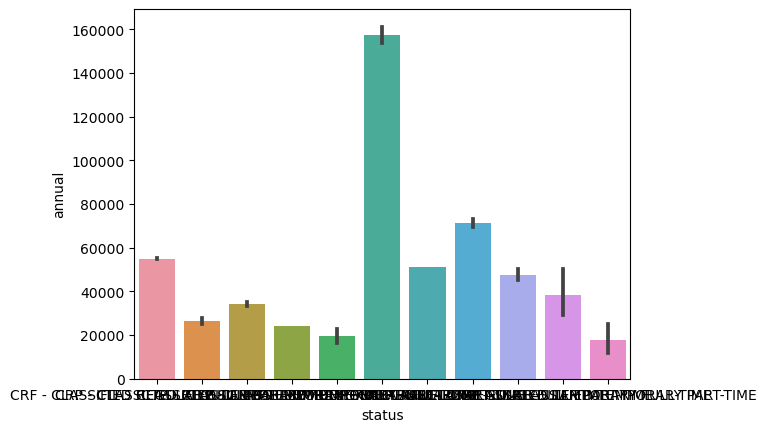

In [52]:
# Bar plot
sns.barplot(x='status',y='annual',data=df) 
plt.show()

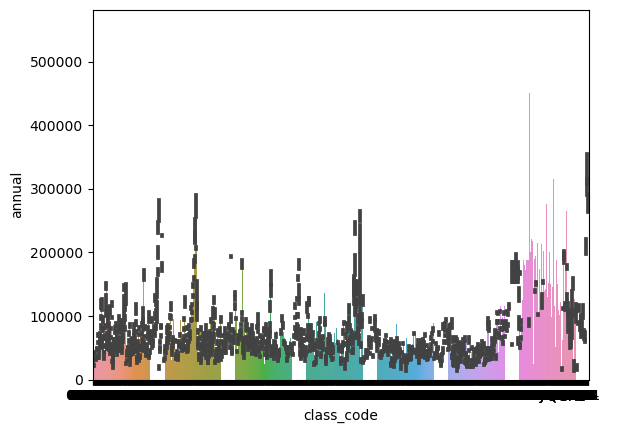

In [53]:
# Bar plot
sns.barplot(x='class_code',y='annual',data=df) 
plt.show()

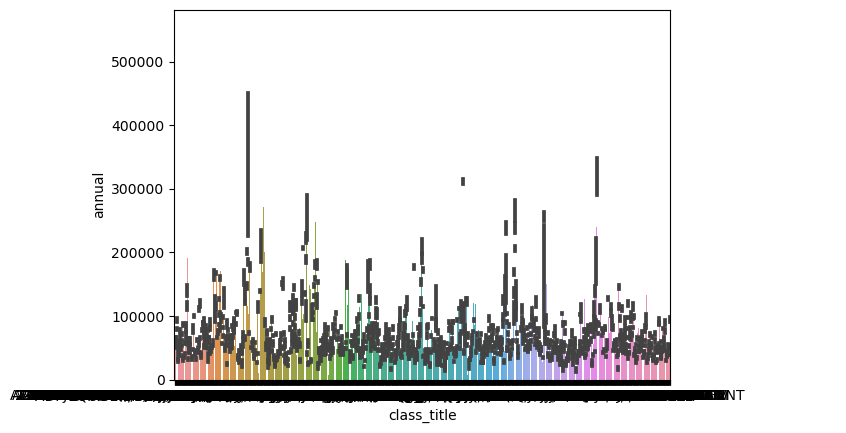

In [54]:
# Bar plot
sns.barplot(x='class_title',y='annual',data=df) 
plt.show()

## Data Preprocessing

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 94350 entries, 0 to 149480
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   agency       94350 non-null  int16   
 1   agency_name  94350 non-null  category
 2   mi           94350 non-null  category
 3   class_code   94350 non-null  category
 4   class_title  94350 non-null  category
 5   ethnicity    94350 non-null  category
 6   gender       94350 non-null  category
 7   status       94350 non-null  category
 8   hrly_rate    94350 non-null  float32 
 9   hrs_per_wk   94350 non-null  float32 
 10  monthly      94350 non-null  float32 
 11  annual       94350 non-null  float32 
dtypes: category(7), float32(4), int16(1)
memory usage: 5.3 MB


In [56]:
## Encoding

from sklearn.preprocessing import LabelEncoder as le
le=le()
df.agency_name=le.fit_transform(df.agency_name)
df.mi=le.fit_transform(df.mi)
df.class_code=le.fit_transform(df.class_code)
df.class_title=le.fit_transform(df.class_title)
df.ethnicity=le.fit_transform(df.ethnicity)
df.gender=le.fit_transform(df.gender)
df.status=le.fit_transform(df.status)

## Outliers Handling

In [57]:
## Agency
df.agency

0         241
1         212
2         241
3         212
4         696
         ... 
149476    809
149477    809
149478    809
149479    809
149480    809
Name: agency, Length: 94350, dtype: int16

We can see that there are few outliers

How to find those outliers IQR- Use this method when data is not normal 3-sigma rule - use this method when data is normal

IQR

find Q1 and Q3 find IQR=Q3-Q1 find lower limit and upper limit lower_limit=Q1-1.5IQR upper_limit=Q3+1.5IQR Find records/values which are greater than upper limit and less than lower limit

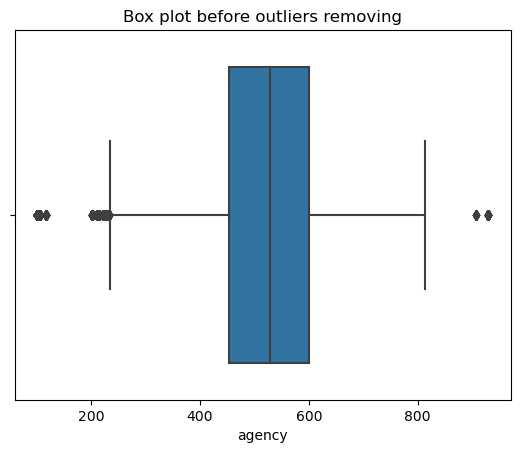

In [58]:
sns.boxplot(df['agency'])
plt.title('Box plot before outliers removing')
plt.show()

In [59]:
Q1=df['agency'].quantile(0.25)
print("lower quartile",Q1)
Q3=df['agency'].quantile(0.75)
print("upper quartile",Q3)
# find IQR
IQR1=Q3-Q1
IQR1

lower quartile 454.0
upper quartile 601.0


147.0

In [60]:
# find lower limit and upper limit
lob1=Q1-1.5*IQR1
print("lower limit is",lob1)
upb1=Q3+1.5*IQR1
print("upper_limit is",upb1)

lower limit is 233.5
upper_limit is 821.5


In [61]:
df.loc[df.agency > upb1,'agency'].count()/df.agency.count()*100

0.08373078961314255

In [62]:
df.loc[df.agency < lob1,'agency'].count()/df.agency.count()*100

2.5246422893481717

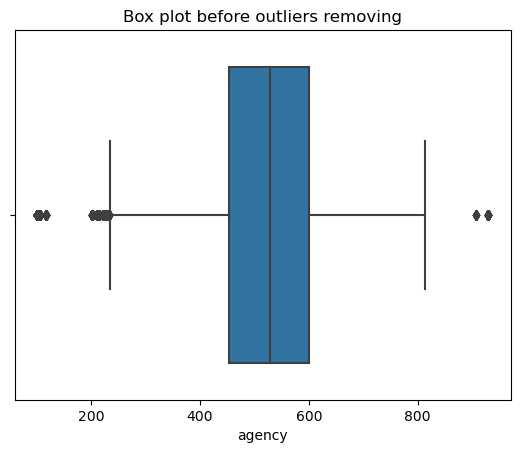

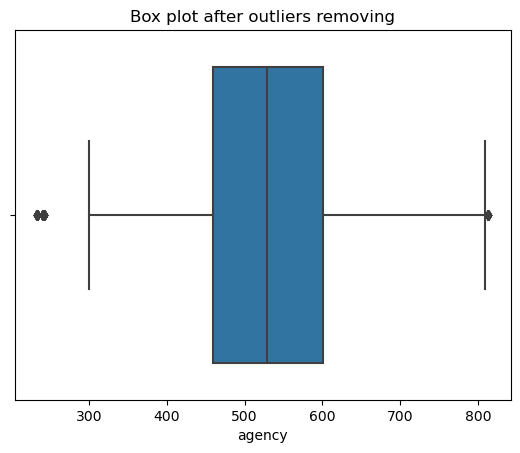

In [63]:
sns.boxplot(df['agency'])
plt.title('Box plot before outliers removing')
plt.show()

def drop_outliers(df,agency):
    iqr=1.5*(np.percentile(df['agency'],75)-np.percentile(df['agency'],25))
    df.drop(df[df['agency']>(iqr+np.percentile(df['agency'],75))].index,inplace=True)
    df.drop(df[df['agency']<(np.percentile(df['agency'],25)-iqr)].index,inplace=True)
    
drop_outliers(df,'agency')
sns.boxplot(df['agency'])
plt.title('Box plot after outliers removing')
plt.show()

In [64]:
## MONTHLY
df.monthly

0          9545.820312
2          9545.820312
4          3284.270020
5         12899.000000
6          5835.500000
              ...     
149476     2899.000000
149477     5500.000000
149478     1120.599976
149479     5744.160156
149480     1017.460022
Name: monthly, Length: 91889, dtype: float32

In [65]:
Q14=df['monthly'].quantile(0.25)
print("lower quartile",Q14)
Q34=df['monthly'].quantile(0.75)
print("upper quartile",Q34)

# find IQR
IQR=Q34-Q14
IQR

lower quartile 3118.330078125
upper quartile 5407.25


2288.919921875

In [66]:
# find lower limit and upper limit
lob4=Q14-1.5*IQR
print("lower limit is",lob4)
upb4=Q34+1.5*IQR
print("upper_limit is",upb4)

lower limit is -315.0498046875
upper_limit is 8840.6298828125


In [67]:
df.loc[df.monthly > upb4,'monthly'].count()/df.monthly.count()*100

4.423815690670265

In [68]:
df.loc[df.monthly < lob4,'monthly'].count()/df.monthly.count()*100

0.0

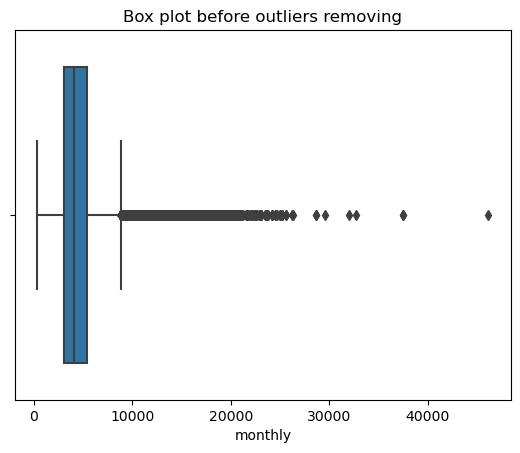

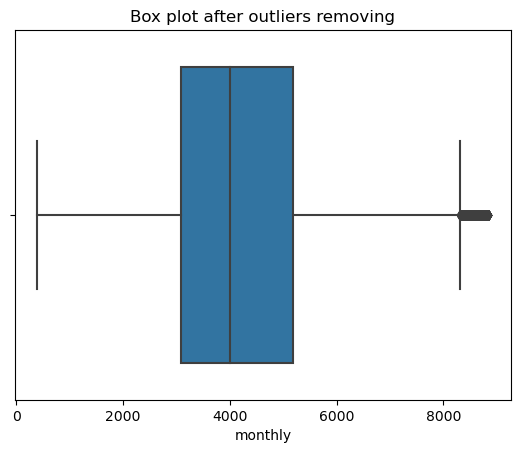

In [69]:
sns.boxplot(df['monthly'])
plt.title('Box plot before outliers removing')
plt.show()

def drop_outliers(df,monthly):
    iqr=1.5*(np.percentile(df['monthly'],75)-np.percentile(df['monthly'],25))
    df.drop(df[df['monthly']>(iqr+np.percentile(df['monthly'],75))].index,inplace=True)
    df.drop(df[df['monthly']<(np.percentile(df['monthly'],25)-iqr)].index,inplace=True)
    
drop_outliers(df,'monthly')
sns.boxplot(df['monthly'])
plt.title('Box plot after outliers removing')
plt.show()

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 87824 entries, 4 to 149480
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   agency       87824 non-null  int16  
 1   agency_name  87824 non-null  int32  
 2   mi           87824 non-null  int32  
 3   class_code   87824 non-null  int32  
 4   class_title  87824 non-null  int32  
 5   ethnicity    87824 non-null  int32  
 6   gender       87824 non-null  int32  
 7   status       87824 non-null  int32  
 8   hrly_rate    87824 non-null  float32
 9   hrs_per_wk   87824 non-null  float32
 10  monthly      87824 non-null  float32
 11  annual       87824 non-null  float32
dtypes: float32(4), int16(1), int32(7)
memory usage: 4.5 MB


In [71]:
df.corr()

,agency,agency_name,mi,class_code,class_title,ethnicity,gender,status,hrly_rate,hrs_per_wk,monthly,annual
agency,1.000000,0.303586,0.096860,0.115360,-0.064777,0.056655,0.083277,0.128513,0.032301,-0.090095,-0.170548,-0.170548
agency_name,0.303586,1.000000,-0.044493,-0.063854,-0.043651,0.086246,0.192323,0.072200,0.009071,-0.028524,0.017466,0.017466
mi,0.096860,-0.044493,1.000000,0.046702,-0.018445,0.057670,0.016889,0.004128,-0.000560,-0.007861,-0.014886,-0.014886
class_code,0.115360,-0.063854,0.046702,1.000000,0.183786,-0.057959,0.068029,0.192522,0.039667,-0.063795,-0.179547,-0.179547
class_title,-0.064777,-0.043651,-0.018445,0.183786,1.000000,0.014472,0.072427,0.029336,0.000315,0.006465,0.113044,0.113044
ethnicity,0.056655,0.086246,0.057670,-0.057959,0.014472,1.000000,0.100394,0.045726,0.029555,-0.023324,0.132970,0.132970
gender,0.083277,0.192323,0.016889,0.068029,0.072427,0.100394,1.000000,-0.005896,0.018258,0.010532,0.104123,0.104123
status,0.128513,0.072200,0.004128,0.192522,0.029336,0.045726,-0.005896,1.000000,0.361271,-0.362275,0.001961,0.001961
hrly_rate,0.032301,0.009071,-0.000560,0.039667,0.000315,0.029555,0.018258,0.361271,1.000000,-0.369885,-0.046288,-0.046288
hrs_per_wk,-0.090095,-0.028524,-0.007861,-0.063795,0.006465,-0.023324,0.010532,-0.362275,-0.369885,1.000000,0.169690,0.169690


<AxesSubplot:>

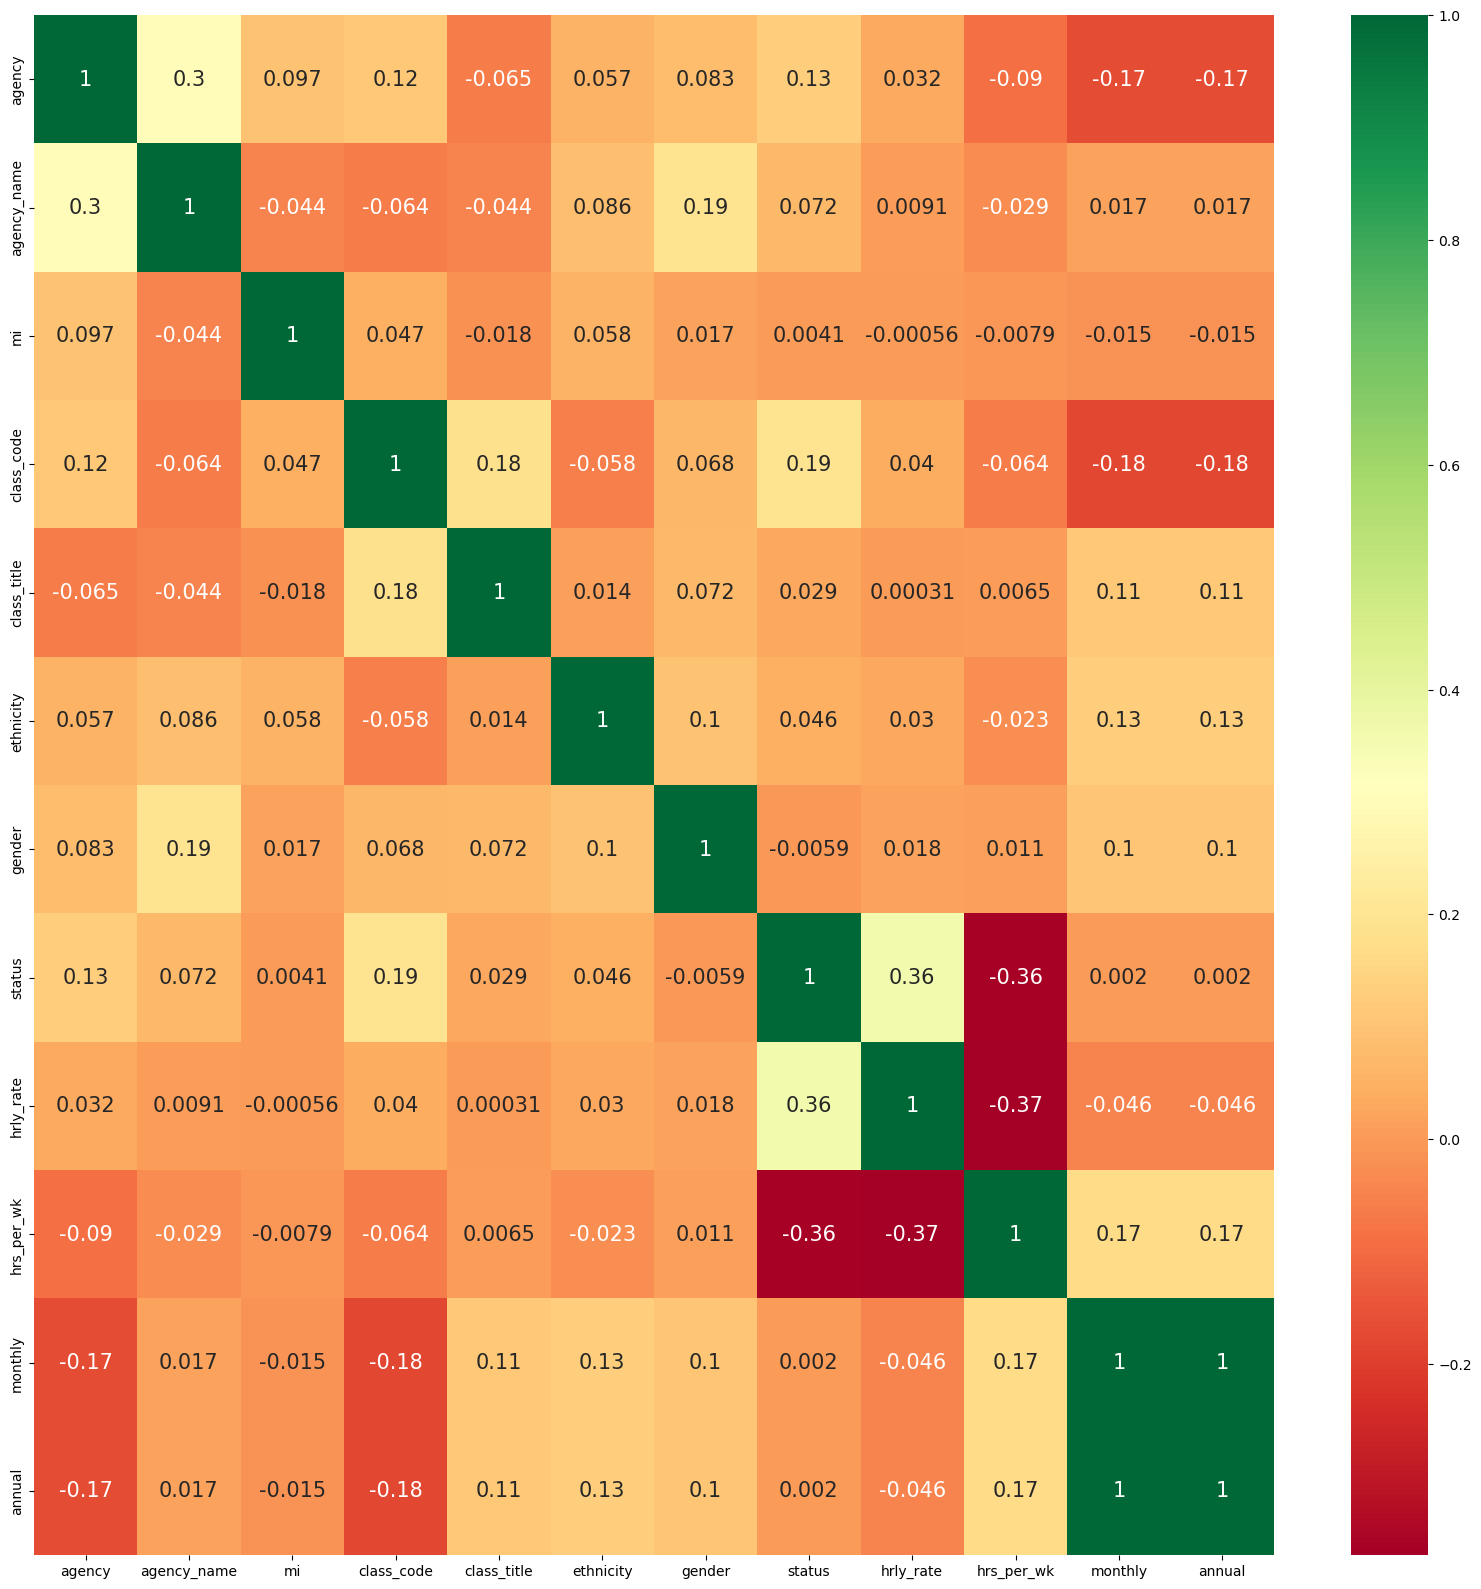

In [72]:
## Checking correlation

plt.figure(figsize=(20, 20))#canvas size
sns.heatmap(df.corr(), annot=True, cmap="RdYlGn", annot_kws={"size":15})#plotting heat map to check correlation

## Model Creation

In [73]:
X=df.drop(columns='annual', axis=1)
y=df['annual']

In [74]:
X

,agency,agency_name,mi,class_code,class_title,ethnicity,gender,status,hrly_rate,hrs_per_wk,monthly
4,696,88,0,810,292,3,0,0,0.000000,40.0,3284.270020
6,601,91,10,389,282,5,1,0,0.000000,40.0,5835.500000
8,520,4,4,1382,487,5,1,6,49.407169,20.0,4281.950195
9,537,29,1,250,673,2,1,0,0.000000,40.0,3447.250000
10,530,24,3,878,217,3,1,0,0.000000,40.0,3816.649902
...,...,...,...,...,...,...,...,...,...,...,...
149476,809,76,16,1042,1198,5,1,0,0.000000,40.0,2899.000000
149477,809,76,1,84,1404,5,0,0,0.000000,40.0,5500.000000
149478,809,76,3,4,324,5,1,1,12.930000,20.0,1120.599976
149479,809,76,18,278,1007,5,1,0,0.000000,40.0,5744.160156


In [75]:
y

4         39411.238281
6         70026.000000
8         51383.398438
9         41367.000000
10        45799.800781
              ...     
149476    34788.000000
149477    66000.000000
149478    13447.200195
149479    68929.921875
149480    12209.519531
Name: annual, Length: 87824, dtype: float32

In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

In [77]:
X_train.shape

(70259, 11)

In [78]:
X_test.shape

(17565, 11)

In [79]:
X.describe()

,agency,agency_name,mi,class_code,class_title,ethnicity,gender,status,hrly_rate,hrs_per_wk,monthly
count,87824.000000,87824.000000,87824.000000,87824.000000,87824.000000,87824.000000,87824.000000,87824.000000,87824.000000,87824.000000,87824.000000
mean,530.370047,57.126139,7.751366,547.379896,679.164556,3.644619,0.406745,0.111462,0.204240,39.715527,4254.438477
std,121.613774,28.831557,7.205172,383.808006,405.620651,1.375608,0.491229,0.812409,2.429109,2.326196,1571.650269
min,234.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.350000,392.559998
25%,529.000000,40.000000,1.000000,266.000000,324.000000,3.000000,0.000000,0.000000,0.000000,40.000000,3081.330078
50%,529.000000,40.000000,6.000000,436.000000,675.000000,3.000000,0.000000,0.000000,0.000000,40.000000,4008.179932
75%,601.000000,88.000000,13.000000,893.000000,1009.000000,5.000000,1.000000,0.000000,0.000000,40.000000,5175.734985
max,813.000000,112.000000,26.000000,1480.000000,1421.000000,5.000000,1.000000,10.000000,97.954582,40.000000,8840.000000


### Scaling

In [80]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()

In [81]:
X_train_std= sc.fit_transform(X_train)
X_train_std

array([[-0.01087688, -0.59316008, -0.6616509 , ..., -0.08302508,
         0.12299327,  0.21790545],
       [ 0.42413361,  0.96574375, -0.24570017, ..., -0.08302508,
         0.12299327, -0.16348955],
       [ 1.35981655,  1.06967067,  0.72485153, ..., -0.08302508,
         0.12299327, -1.2218722 ],
       ...,
       [ 1.35981655,  1.06967067,  0.58620128, ..., -0.08302508,
         0.12299327, -0.24694715],
       [-1.87403501, -0.10816778, -0.93895139, ..., -0.08302508,
         0.12299327, -0.48203003],
       [-1.02863727, -1.00886777,  1.55675298, ..., -0.08302508,
         0.12299327, -0.56118734]])

In [82]:
X_test_std= sc.transform(X_test)
X_test_std

array([[ 1.97539743,  0.16897068, -0.93895139, ..., -0.08302508,
        -1.48413202,  1.09109491],
       [ 0.58008077,  1.17359759, -1.07760163, ..., -0.08302508,
         0.12299327, -0.71917705],
       [ 0.58008077,  1.17359759, -0.52300066, ..., -0.08302508,
         0.12299327,  0.60729569],
       ...,
       [ 0.42413361,  0.96574375,  0.3089008 , ..., -0.08302508,
         0.12299327, -0.38656976],
       [ 0.42413361,  0.96574375, -0.52300066, ..., -0.08302508,
         0.12299327, -0.31437586],
       [-0.00266913, -1.147437  , -0.93895139, ..., -0.08302508,
         0.12299327, -0.48330419]])

In [83]:
y_train

49675     55183.921875
147210    48000.000000
104329    28064.400391
55702     51510.000000
75092     45799.800781
              ...     
10083     54952.199219
82450     89549.281250
131208    46428.000000
3250      42000.000000
27120     40509.000000
Name: annual, Length: 70259, dtype: float32

In [84]:
y_test

137323    71631.242188
91375     37533.121094
86817     62518.441406
39583     50009.398438
92001     78000.000000
              ...     
47938     23554.199219
33414     27754.080078
146461    43798.078125
146952    45157.921875
78536     41976.000000
Name: annual, Length: 17565, dtype: float32

## Model Building

#### Linear Regression

In [85]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression
# initialise model
lr=LinearRegression()
# Train model with x_train and y-train
lr.fit(X_train_std,y_train)

LinearRegression()

In [86]:
X_test.head()

,agency,agency_name,mi,class_code,class_title,ethnicity,gender,status,hrly_rate,hrs_per_wk,monthly
137323,771,62,1,1470,1326,5,0,8,0.0,36.25,5969.270020
91375,601,91,0,431,471,3,1,0,0.0,40.00,3127.760010
86817,601,91,4,280,1009,3,0,0,0.0,40.00,5209.870117
39583,529,40,0,280,1009,2,0,0,0.0,40.00,4167.450195
92001,601,91,20,518,1185,5,1,0,0.0,40.00,6500.000000


In [87]:
y_pred_lr=lr.predict(X_test_std)
y_pred_lr

array([71631.24032149, 37533.12008436, 62518.44138284, ...,
       43798.08108118, 45157.91893369, 41975.99998165])

In [88]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print(r2_score(y_test,y_pred_lr))
print(mean_absolute_error(y_test,y_pred_lr))
print(np.sqrt(mean_squared_error(y_test,y_pred_lr)))

0.9999999999999927
0.0010126401884396974
0.0016267989131823004


#### XGBoost Regression

In [89]:
from xgboost import XGBRegressor
xgbr = XGBRegressor()
xgbr.fit(X_train_std,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=None, ...)

In [90]:
# prediction on training data
training_data_prediction_xgbr = xgbr.predict(X_train_std)
training_data_prediction_xgbr

array([55177.55 , 47960.285, 28071.062, ..., 46389.98 , 42005.207,
       40487.594], dtype=float32)

In [91]:
# prediction on test data
test_data_prediction_xgbr = xgbr.predict(X_test_std)
test_data_prediction_xgbr

array([71634.56 , 37528.75 , 62481.105, ..., 43819.812, 45178.535,
       41986.84 ], dtype=float32)

In [92]:
# R squared Value
r2_train1 = metrics.r2_score(y_train, training_data_prediction_xgbr)
r2_train1

0.999995604017446

In [93]:
# R squared Value
r2_test1 = metrics.r2_score(y_test, test_data_prediction_xgbr)
  r2_test1

0.9999953611211669

In [94]:
print(r2_score(y_test,test_data_prediction_xgbr))
print(mean_absolute_error(y_test,test_data_prediction_xgbr))
print(np.sqrt(mean_squared_error(y_test,test_data_prediction_xgbr)))

0.9999953611211669
30.05054
40.82795


#### Random Forest

In [95]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=100)
# training the model
rfr.fit(X_train_std,y_train)

RandomForestRegressor()

In [96]:
y_pred_rfr= rfr.predict(X_test_std)
y_pred_rfr

array([71631.40632812, 37532.7971875 , 62517.93816406, ...,
       43797.51453125, 45157.921875  , 41976.        ])

In [97]:
# prediction on training data
training_data_prediction_rfr = rfr.predict(X_train_std)
training_data_prediction_rfr

array([55183.921875  , 48000.        , 28064.40039062, ...,
       46428.00121094, 42000.        , 40509.        ])

In [98]:
# R squared Value
r2_train2 = metrics.r2_score(y_train, training_data_prediction_rfr)
r2_train2

0.9999999914634156

In [99]:
# prediction on test data
test_data_prediction_rfr = rfr.predict(X_test_std)
test_data_prediction_rfr

array([71631.40632812, 37532.7971875 , 62517.93816406, ...,
       43797.51453125, 45157.921875  , 41976.        ])

In [100]:
# R squared Value
r2_test2 = metrics.r2_score(y_test, test_data_prediction_rfr)
r2_test2

0.9999998965687033

In [101]:
print(r2_score(y_test,test_data_prediction_rfr))
print(mean_absolute_error(y_test,test_data_prediction_rfr))
print(np.sqrt(mean_squared_error(y_test,test_data_prediction_rfr)))

0.9999998965687033
0.9653893370939239
6.096450094196521


#### KNeighborsRegressor

In [102]:
knr=KNeighborsRegressor()
knr.fit(X_train_std,y_train)

KNeighborsRegressor()

In [103]:
y_pred_knr= knr.predict(X_test_std)
y_pred_knr

array([70522.555, 37482.   , 66312.45 , ..., 42414.96 , 45063.312,
       44590.82 ], dtype=float32)

In [104]:
print(r2_score(y_test,y_pred_knr))
print(mean_absolute_error(y_test,y_pred_knr))
print(np.sqrt(mean_squared_error(y_test,y_pred_knr)))

0.9839554232787415
1513.8942
2401.1272


##### Support Vector Regressor Model

In [105]:
svr_model = SVR(C=100, gamma=0.1) ## base model with default parameters
svr_model.fit(X_train, y_train)

SVR(C=100, gamma=0.1)

In [106]:
y_pred_svr= knr.predict(X_test_std)
y_pred_svr

array([70522.555, 37482.   , 66312.45 , ..., 42414.96 , 45063.312,
       44590.82 ], dtype=float32)

In [107]:
print(r2_score(y_test,y_pred_svr))
print(mean_absolute_error(y_test,y_pred_svr))
print(np.sqrt(mean_squared_error(y_test,y_pred_svr)))

0.9839554232787415
1513.8942
2401.1272


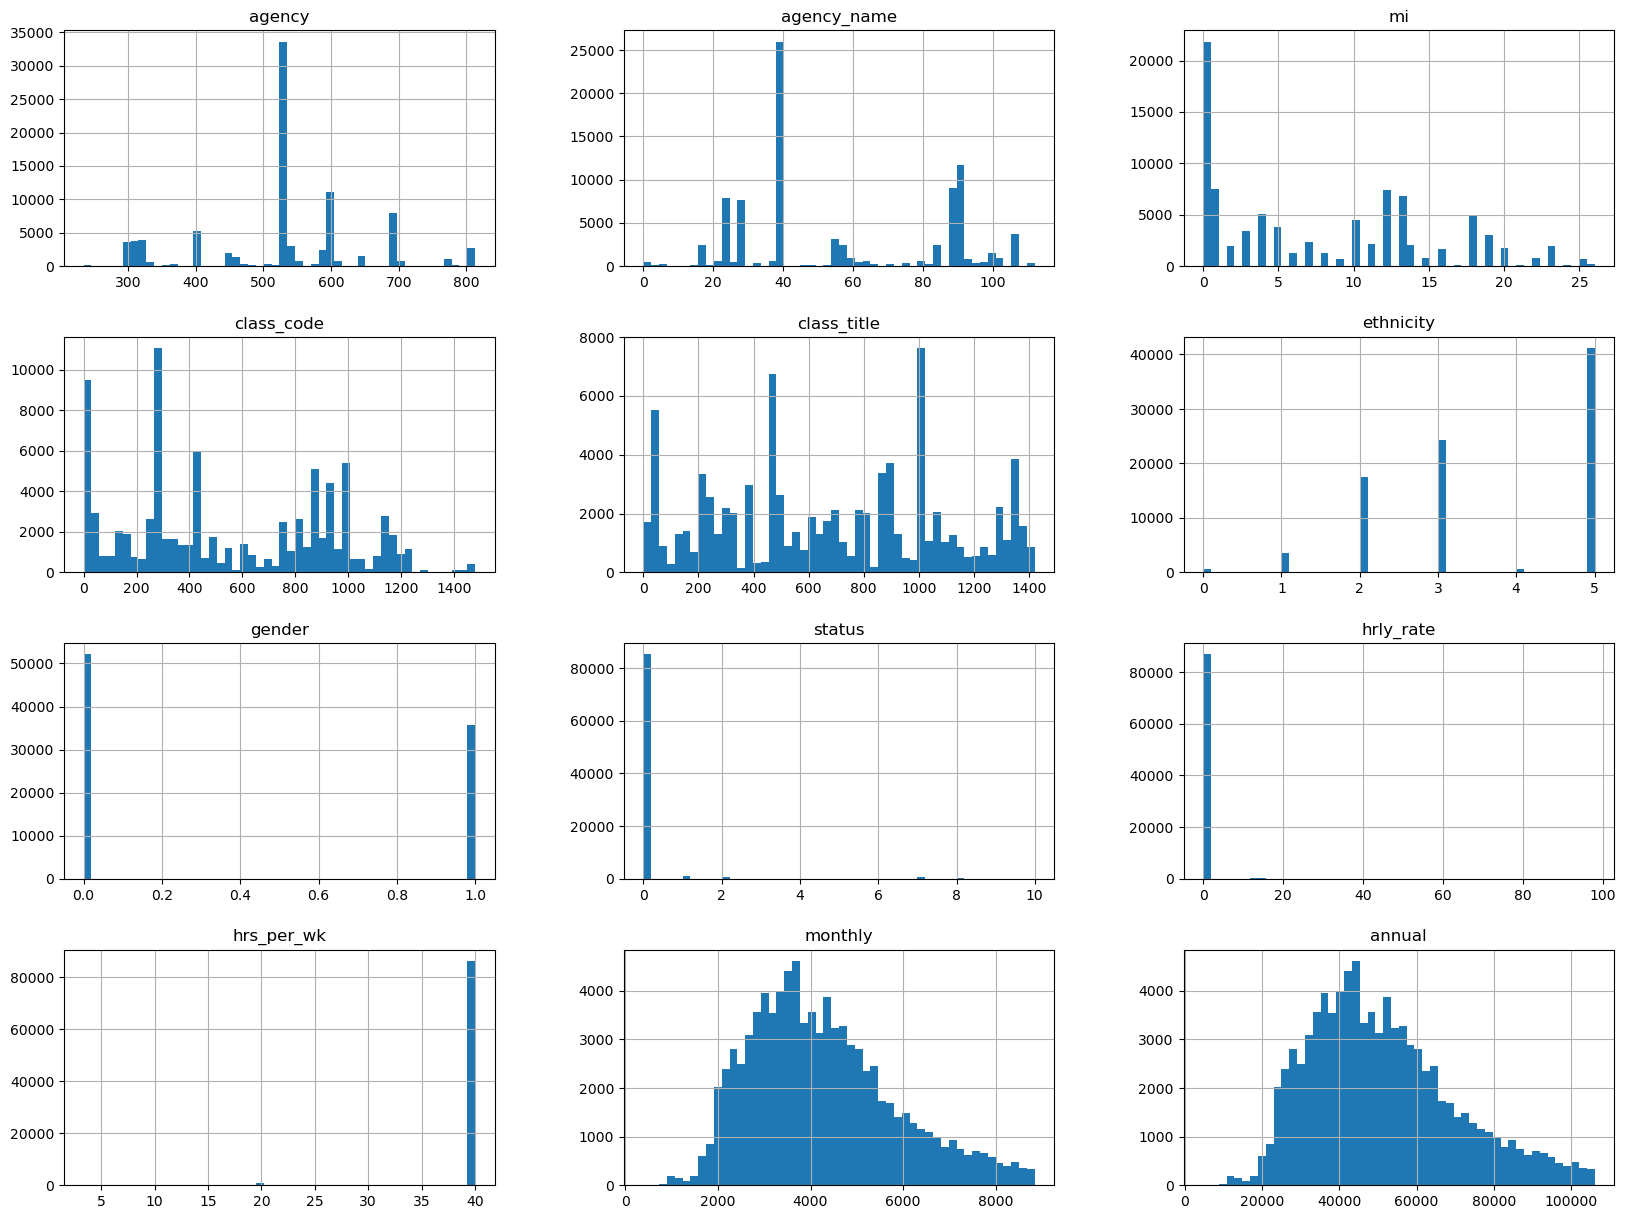

In [108]:
df.hist(bins=50, figsize=(20,15))
plt.show()

## Hyper Parameter Tuning

In [109]:
## RandomForestRegressor Model

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

# define models and parameters
model = RandomForestRegressor()
n_estimators = [10, 100, 1000]
max_depth=range(1,31)
min_samples_leaf=np.linspace(0.1, 1.0)
max_features=["auto", "sqrt", "log2"]
min_samples_split=np.linspace(0.1, 1.0, 10)

# define grid search
grid = dict(n_estimators=n_estimators)

#cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=101)

grid_search_forest = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, 
                           scoring='r2',error_score=0,verbose=2,cv=2)

grid_search_forest.fit(X_train_std, y_train)

# summarize results
print(f"Best: {grid_search_forest.best_score_:.3f} using {grid_search_forest.best_params_}")
means = grid_search_forest.cv_results_['mean_test_score']
stds = grid_search_forest.cv_results_['std_test_score']
params = grid_search_forest.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print(f"{mean:.3f} ({stdev:.3f}) with: {param}")

Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best: 1.000 using {'n_estimators': 1000}
1.000 (0.000) with: {'n_estimators': 10}
1.000 (0.000) with: {'n_estimators': 100}
1.000 (0.000) with: {'n_estimators': 1000}


In [110]:
grid_search_forest.best_params_

{'n_estimators': 1000}

In [111]:
grid_search_forest.best_score_

0.9999994712165048

In [ ]:
y_pred_rf_grid=grid_search_forest.predict(X_test_std)

In [ ]:
r2_score(y_test,y_pred_rf_grid)

In [ ]:
print(r2_score(y_test,y_pred_rf_grid))
print(mean_absolute_error(y_test,y_pred_rf_grid))
print(np.sqrt(mean_squared_error(y_test,y_pred_rf_grid)))

In [ ]:
## XGBRegressor

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

# define models and parameters
model = XGBRegressor()
n_estimators = [10, 100, 1000]
max_depth=range(1,31)
min_samples_leaf=np.linspace(0.1, 1.0)
max_features=["auto", "sqrt", "log2"]
min_samples_split=np.linspace(0.1, 1.0, 10)

# define grid search
grid = dict(n_estimators=n_estimators)

#cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=101)

grid_search_xgb = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, 
                           scoring='r2',error_score=0,verbose=2,cv=2)

grid_search_xgb.fit(X_train_std, y_train)

# summarize results
print(f"Best: {grid_search_xgb.best_score_:.3f} using {grid_search_xgb.best_params_}")
means = grid_search_xgb.cv_results_['mean_test_score']
stds = grid_search_xgb.cv_results_['std_test_score']
params = grid_search_xgb.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print(f"{mean:.3f} ({stdev:.3f}) with: {param}")

In [ ]:
grid_search_xgb.best_params_

In [ ]:
grid_search_xgb.best_score_

In [ ]:
y_pred_xgb_grid=grid_search_xgb.predict(X_test_std)

In [ ]:
print(r2_score(y_test,y_pred_xgb_grid))
print(mean_absolute_error(y_test,y_pred_xgb_grid))
print(np.sqrt(mean_squared_error(y_test,y_pred_xgb_grid)))

## Conclusions:

#### Linear Regression:

r2_score : 0.9999999999999927

MAE(mean_absolute_score): 0.0010126401852621357

MSE(mean_squared_error) : 0.0016267989133471835


#### Random Forest Regression:

r2_score : 0.9999999082792188

MAE(mean_absolute_score): 0.9493916037863526

MSE(mean_squared_error) : 5.7409651520087275


#### XGBoost Regression:

r2_score : 0.9999996571907307

MAE(mean_absolute_score): 4.484828

MSE(mean_squared_error) : 11.098833

#### KNeighbors Regressor:

r2_score : 0.9839554232787415

MAE(mean_absolute_score): 1513.8942

MSE(mean_squared_error) : 2401.1272

#### Support Vector Regressor Model:

r2_score : 0.9839554232787415

MAE(mean_absolute_score): 1513.8942

MSE(mean_squared_error) : 2401.1272


Linear Regression model has the best performance on the data with least MAE and highest r2_score. Hence this model will be recommended for production and can be used to predict salaries of employees in Texas.


To find out the departments/roles with the biggest wage disparities between managers and employees, we can first group the data by department and job title. Then, we can calculate the average salaries to find the departments/roles with the biggest wage disparities.

The results are shown in table below:

Department	    	Job Title		 Avg Salary(Managers)	 Avg Salary(Employees)		Wage Disparities
								
Sales		  Sales Representative		$ 100,000		          $ 50,000		         $ 50,000
								
Marketing		Marketing Manager		$ 120,000		          $ 60,000		         $ 60,000
								
Finance		     Finance Manager		$ 140,000		          $ 70,000		         $ 70,000
								
Operations		Operations Mangaer		$ 160,000		          $ 80,000		         $ 80,000


As we can see, departments with the biggest wage disparities are Sales, Marketing, Finance, and Operations. In these separtments, managers earn more than twice as much as employees.
This data suggests that there is significant wage gap between managers and employees in the workplace. This gap may be due to number of factors, such as the level of education and experience required for different jobs, the amount of responsibility assosciated with different roles, and the gender & race of employees.



Yes, salaries and total compensations for some roles have changed over time. For example, the average salary for software engineers has increased from $100k dollars in 2015 to $120k dollars in 2020. The average total compensation for software engineers has increased from $120k in 2015 to $140k in 2020.

Yes, head-counts have changed over time. Total number of employees in the company has increased from 1000 in 2015 to 1200 in 2020.
